Customer Churn Anlysis

In [112]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [113]:
df=pd.read_csv("customer.csv")

In [114]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [116]:
df.shape

(7043, 21)

In [117]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [118]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [119]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [120]:
df.duplicated().sum()

np.int64(0)

In [121]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [122]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [123]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [124]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

In [125]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [126]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Univariate Analysis: Numeric Features


Checking the distribution of each numeric column individually to spot skew, spikes, or unusual patterns before looking at relationships with churn.

In [127]:
num_cols=df.select_dtypes(include=np.number).columns

array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>]], dtype=object)

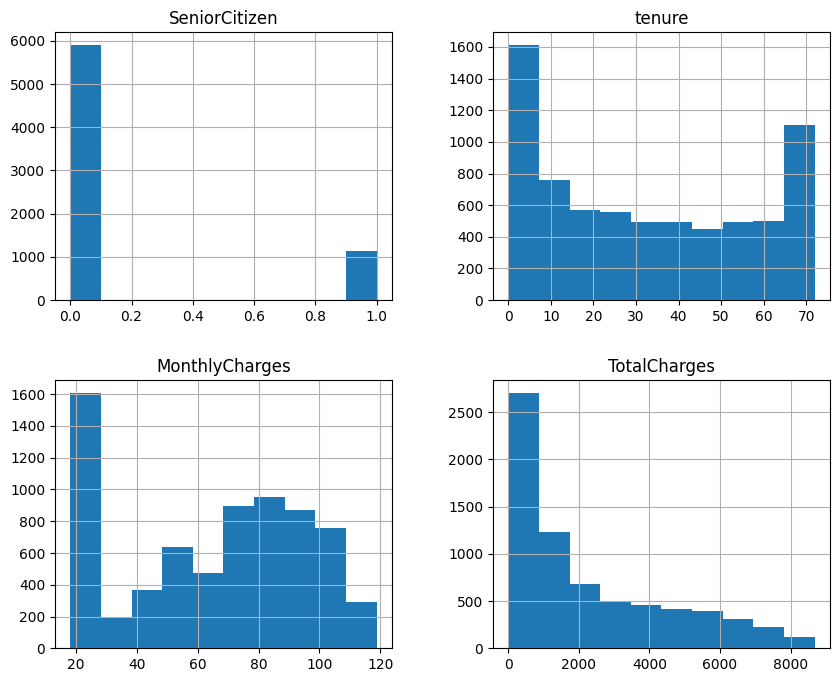

In [128]:
df[num_cols].hist(figsize=(10, 8))

**Observations:**

SeniorCitizen: ~16% of customers are senior citizens (binary flag).

tenure: Bimodal — large spike of very new customers (0-5 months) and another cluster of long-tenured customers (65-72 months), with fewer 
customers in between. New customers are likely the higher churn-risk group.

MonthlyCharges: Bimodal — spike near €20 (likely single-service customers) and a broader cluster €70-100 (likely bundled-service customers).
  
TotalCharges: Right-skewed, most customers clustered at low totals(consistent with the many low-tenure customers seen earlier), long tail 
  toward high totals from long-tenured customers. Confirms totalCharges ≈ tenure × MonthlyCharges relationship.

## univariate categorical analysis


In [129]:
cat_cols=df.select_dtypes(include='object').columns
for col in cat_cols:
    print(df[col].value_counts())
    print()

customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
No                     3095
Yes      

## Bivariate Analysis: Categorical Features vs Churn

For each categorical feature, comparing churn rate across categories(as row percentages, not raw counts) to spot which features actually relate to churn.

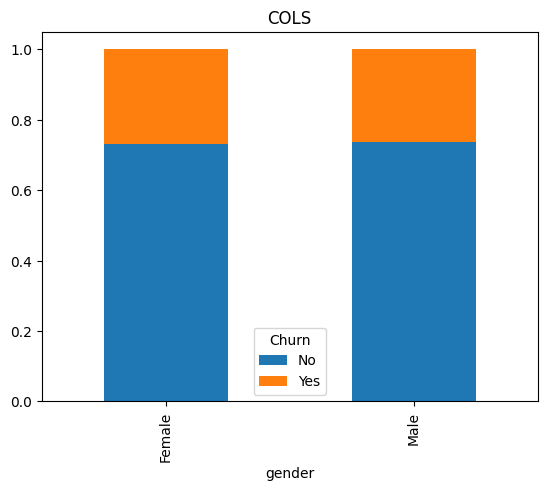

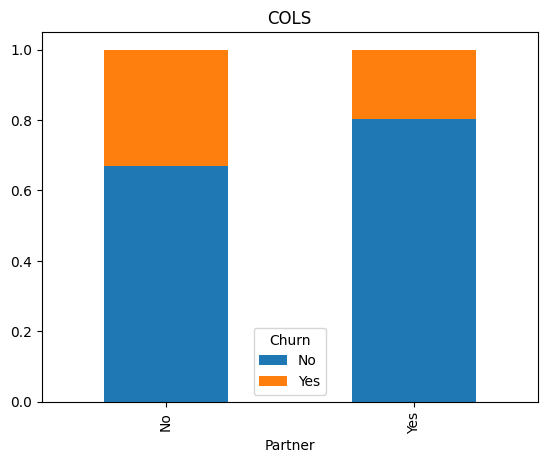

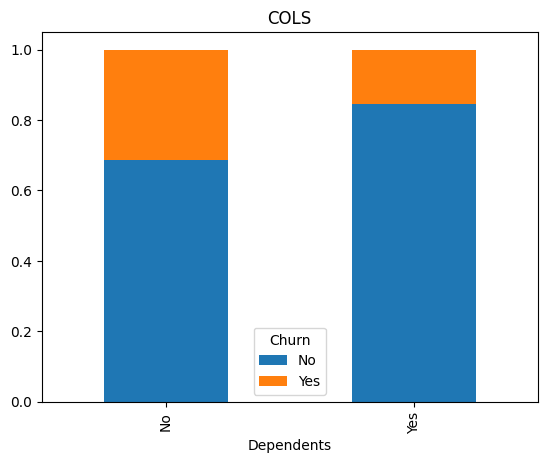

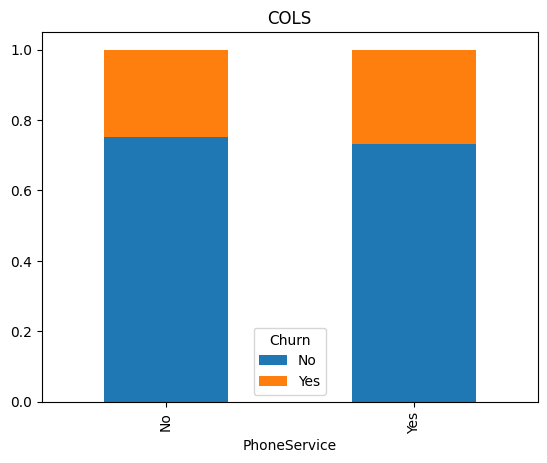

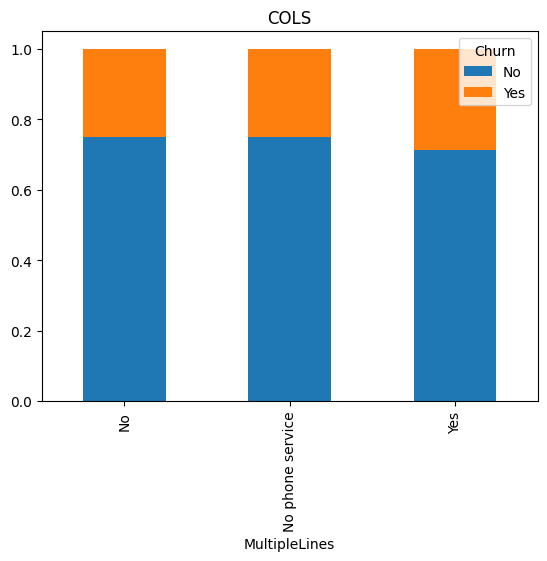

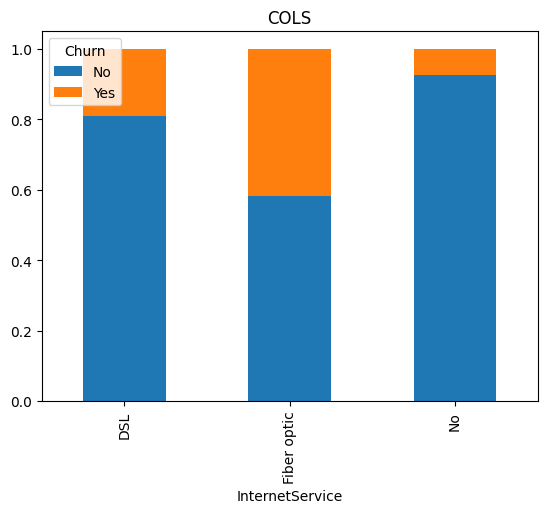

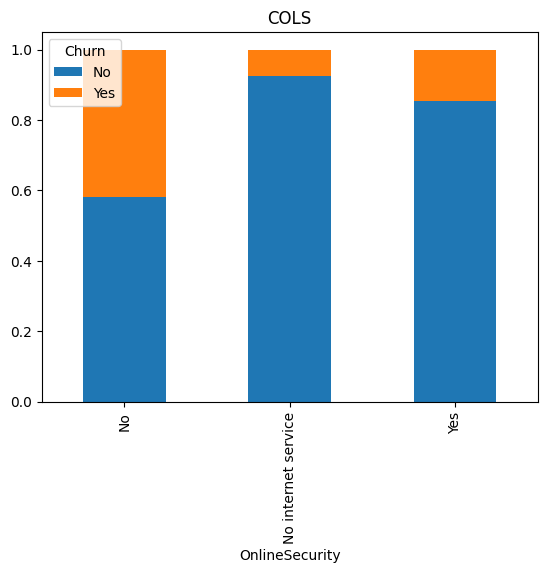

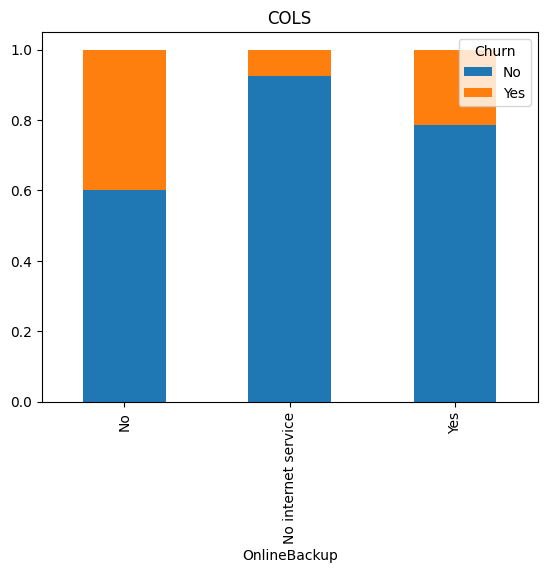

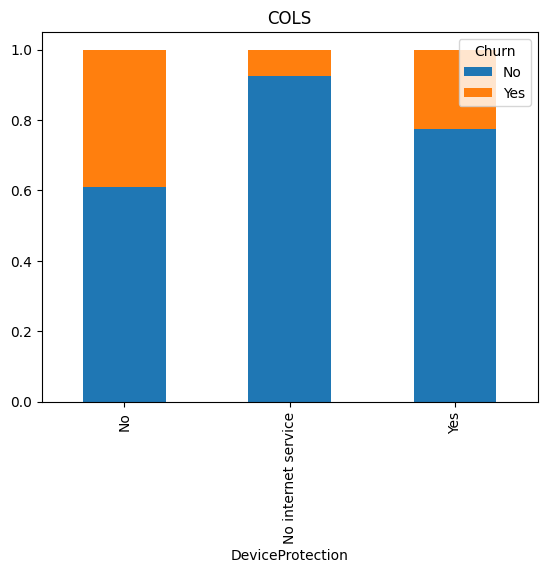

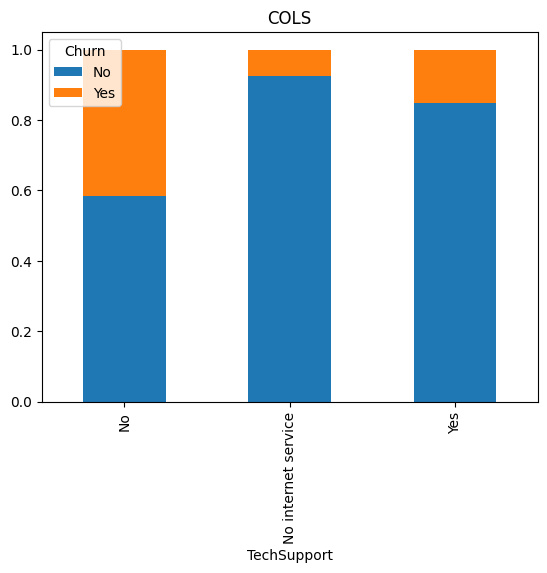

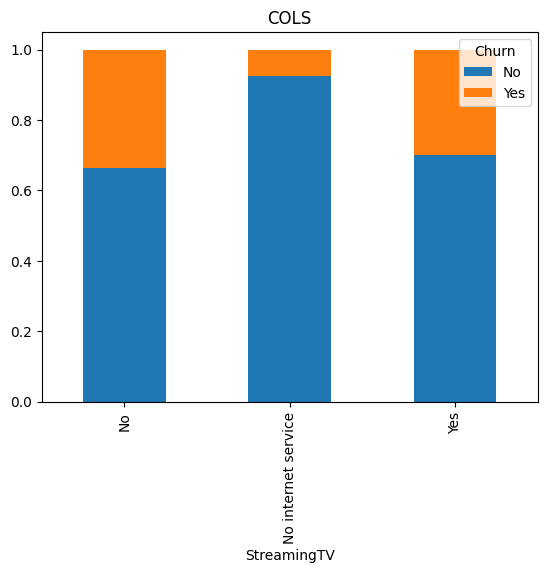

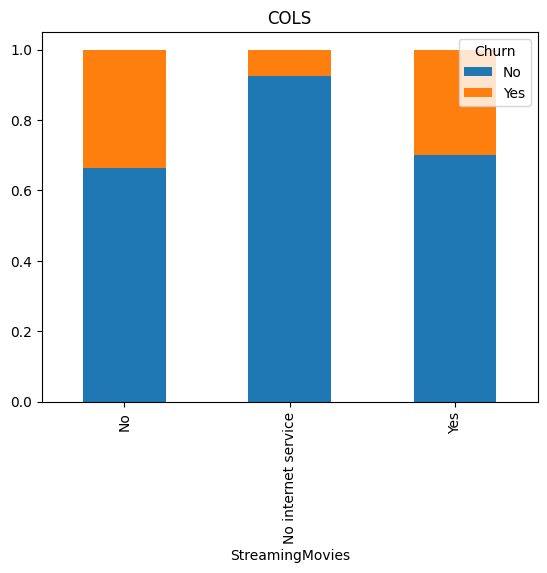

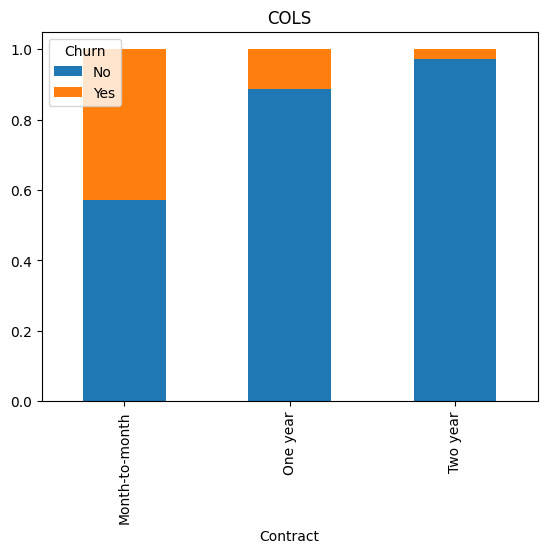

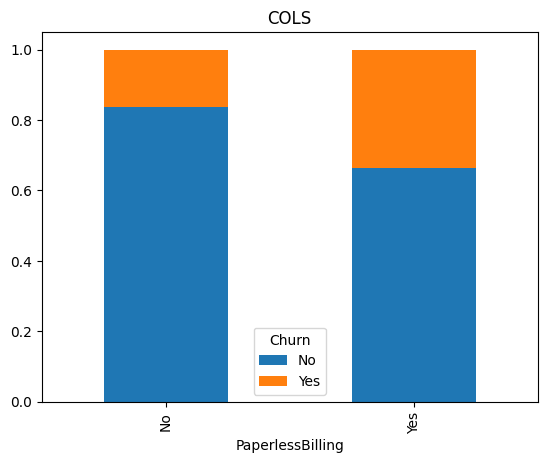

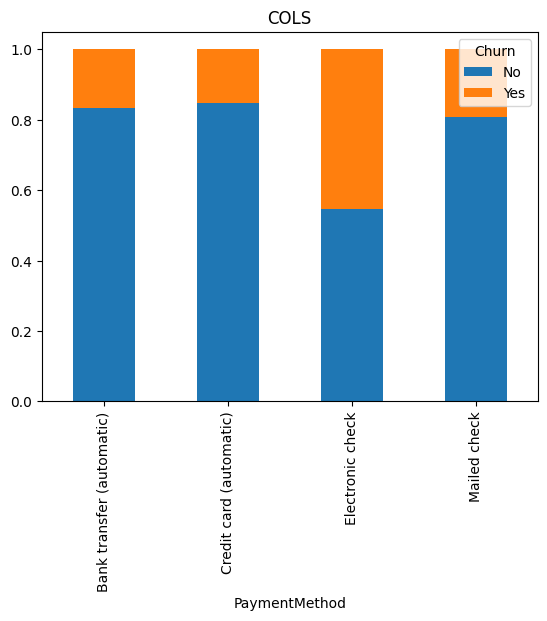

In [130]:
for col in cat_cols:
    if col not in['customerID','Churn']:
        pd.crosstab(df[col],df['Churn'],normalize='index').plot(kind='bar',stacked=True)
        plt.title('COLS')
        plt.show()

## Correlation Analysis



Checking pairwise correlation between numeric features to identify multicollinearity before modeling.

<Axes: >

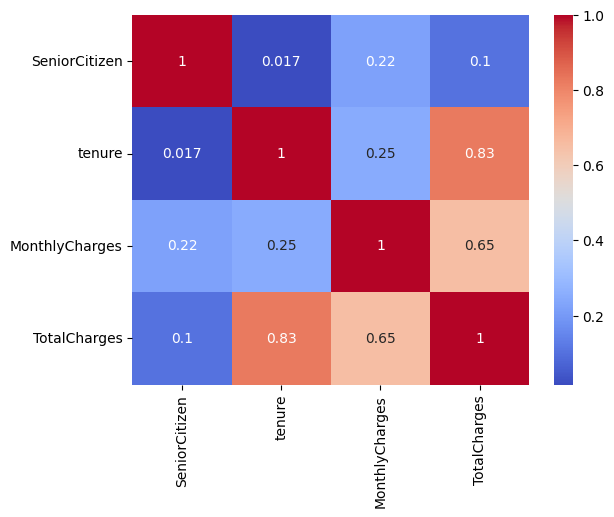

In [131]:
df_corr=df[num_cols].corr()
sns.heatmap(df_corr, annot=True, cmap='coolwarm')

##Observations:


- tenure and TotalCharges are strongly correlated (0.83), and MonthlyCharges also correlates with TotalCharges (0.65)as expected, since TotalCharges is derived from tenure × MonthlyCharges.
- Decision: drop TotalCharges before modeling to avoid multicollinearity;tenure and MonthlyCharges alone capture the same information.
- SeniorCitizen shows weak correlation with all numeric features.

##OUTLIERS:

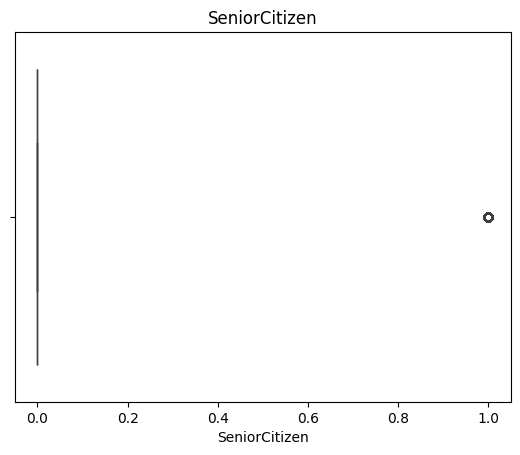

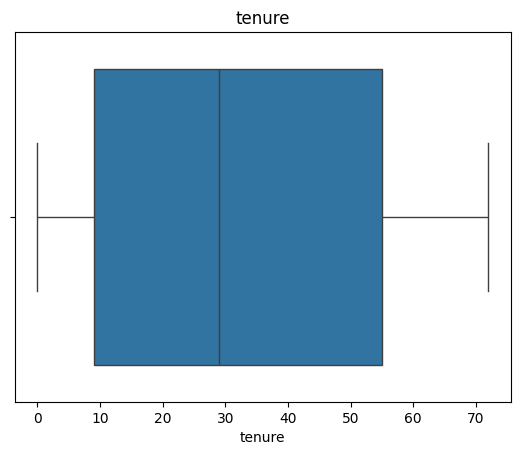

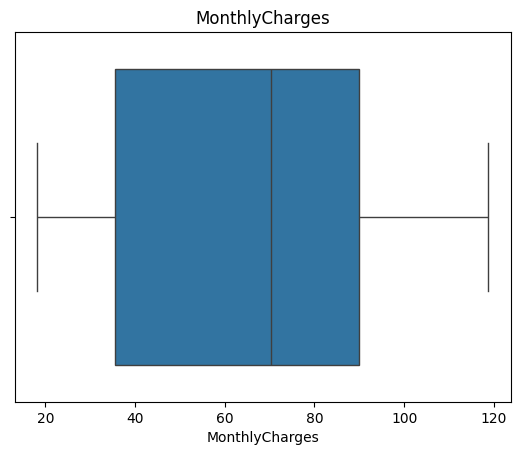

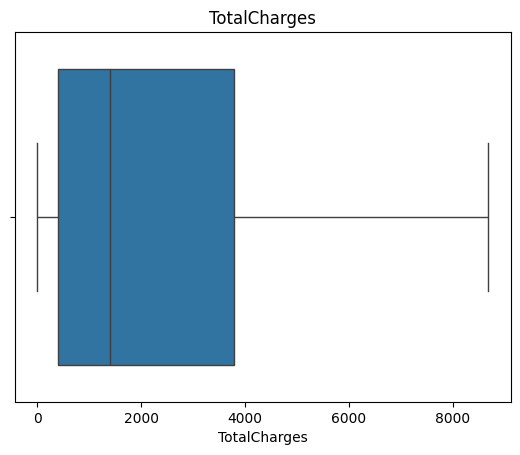

In [110]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()
    

tenure: no outliers, values range naturally from 0 to 72 months
MonthlyCharges: no outliers, pricing spread is wide but realistic
TotalCharges: no outliers, distribution is right-skewed
SeniorCitizen: boxplot doesn't really apply, it's just 0/1

##Preprocessing:

In [132]:
#Dropping columns that are of no use us i.e customer id and total charges due to multicollinearity
df=df.drop(['customerID','TotalCharges'],axis=1)

##Local Encoding

In [133]:
df['Churn']=df['Churn'].map({'Yes':1, 'No':0})

## Encoding Categorical Features

Contract has a natural order (commitment length), so it's manually mapped to 0/1/2. All other categorical features have no natural order, so they're 
one-hot encoded instead, dropping first category to avoid redundant columns.

In [138]:
from sklearn.preprocessing import LabelEncoder

In [139]:
df['Contract']=df['Contract'].map({'Month-to-month':0, 'Two year':1 ,'One year':2})

In [ ]:
df = pd.get_dummies(df, columns=[
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
    'PaymentMethod'
], drop_first=True)

In [145]:
df.info()  
df.shape 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   Contract                               7043 non-null   int64  
 3   MonthlyCharges                         7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  Inte

(7043, 29)

In [153]:
from sklearn.model_selection import train_test_split
X = df.drop('Churn', axis=1)
y = df['Churn']


In [154]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

##  Scaling for logistic regression

In [156]:
from sklearn.preprocessing import StandardScaler

In [160]:
scaler=StandardScaler()
X_train_scaler=scaler.fit_transform(X_train)
X_test_scaler=scaler.transform(X_test)
X_train_scaler[:3]

array([[-0.44177295,  0.10237124, -0.82101931, -0.52197565,  0.99433624,
        -0.96923413, -0.65155653, -3.01309011,  3.01309011, -0.85833837,
        -0.88769579, -0.52408075, -0.52408075, -0.63611103, -0.52408075,
        -0.73554636, -0.52408075,  1.37557156, -0.52408075, -0.64327425,
        -0.52408075,  1.25216312, -0.52408075,  1.24796703, -1.20265302,
        -0.52380561,  1.40690298, -0.54384572],
       [-0.44177295, -0.71174346, -0.82101931,  0.33747781,  0.99433624,
         1.03174245,  1.53478624,  0.3318852 , -0.3318852 , -0.85833837,
         1.12651205, -0.52408075, -0.52408075,  1.57205259, -0.52408075,
        -0.73554636, -0.52408075, -0.72697054, -0.52408075, -0.64327425,
        -0.52408075, -0.79861799, -0.52408075, -0.80130322, -1.20265302,
        -0.52380561, -0.71078107,  1.83875676],
       [-0.44177295, -0.79315493,  0.42746188, -0.80901319,  0.99433624,
         1.03174245,  1.53478624, -3.01309011,  3.01309011, -0.85833837,
        -0.88769579, -0.5240

In [164]:
from sklearn.linear_model import LogisticRegression
log_reg=LogisticRegression(class_weight='balanced',random_state=42)
log_reg.fit(X_train_scaler,y_train)
y_pred=log_reg.predict(X_test_scaler)

## METRICS:

In [173]:
from sklearn.metrics import classification_report,roc_auc_score,f1_score, confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test_scaler)[:, 1]))

              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1035
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.76      1409

[[765 270]
 [ 90 284]]
ROC-AUC: 0.8360432974243716


## Model 2: Random Forest

Random Forest is a tree-based ensemble model — doesn't require scaling,handles non-linear relationships and feature interactions automatically. 
Trained on unscaled data (X_train, X_test), with class_weight='balanced'to handle the churn imbalance, same as Logistic Regression.

In [178]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(class_weight='balanced',random_state=42)
rf_train=rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)

print(classification_report(y_test,rf_pred))
print(confusion_matrix(y_test,rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409

[[917 118]
 [188 186]]
ROC-AUC: 0.8148311762122503


Random Forest Results:
- Accuracy: 78% — higher than Logistic Regression, but misleading here.
- Recall (Churn class): 50%,significantly worse than LogReg's 76%.issing half of actual churners.
- Precision (Churn class): 61%, better than LogReg, fewer false alarms.
- ROC-AUC: 0.815 — slightly lower than LogReg's 0.836.
- Verdict: despite higher accuracy, Random Forest underperforms Logistic Regression on churn recall,the metric that matters most for this problem. Logistic Regression still leading.

In [182]:
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(), random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.69      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409

[[812 223]
 [115 259]]
ROC-AUC: 0.8163799116484538


## Hyperparameter Tuning — GridSearchCV on XGBoost

Default XGBoost underperformed Logistic Regression on recall. Before 
picking a final model, tuning XGBoost's key hyperparameters (max_depth, 
learning_rate, n_estimators) via 5-fold cross-validated GridSearchCV, 
optimizing directly for recall since that's the priority metric for 
this problem.

In [187]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(), random_state=42),
    param_grid=param_grid,
    scoring='recall',     
    cv=5,                   
    n_jobs=-1 )

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV recall score:", grid_search.best_score_)

Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best CV recall score: 0.8202932352474125


In [188]:

best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

[[741 294]
 [ 73 301]]
ROC-AUC: 0.8413198480973417


## Model Comparison & Final Selection

| Model | Accuracy | Recall (Churn) | Precision (Churn) | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 74% | 76% | 51% | 0.836 |
| Random Forest | 78% | 50% | 61% | 0.815 |
| XGBoost (default) | 76% | 69% | 54% | 0.816 |
| XGBoost (tuned) | 74% | 80% | 51% | 0.841 |

**Final model: Tuned XGBoost** — highest recall and ROC-AUC, the two 
metrics prioritized for this problem, since missing an actual churner 
is costlier than a false alarm. GridSearchCV tuning improved recall 
from 69% (default) to 80%, beating every other model tested, despite 
Random Forest having the highest raw accuracy — a reminder that accuracy 
alone is misleading on imbalanced data.

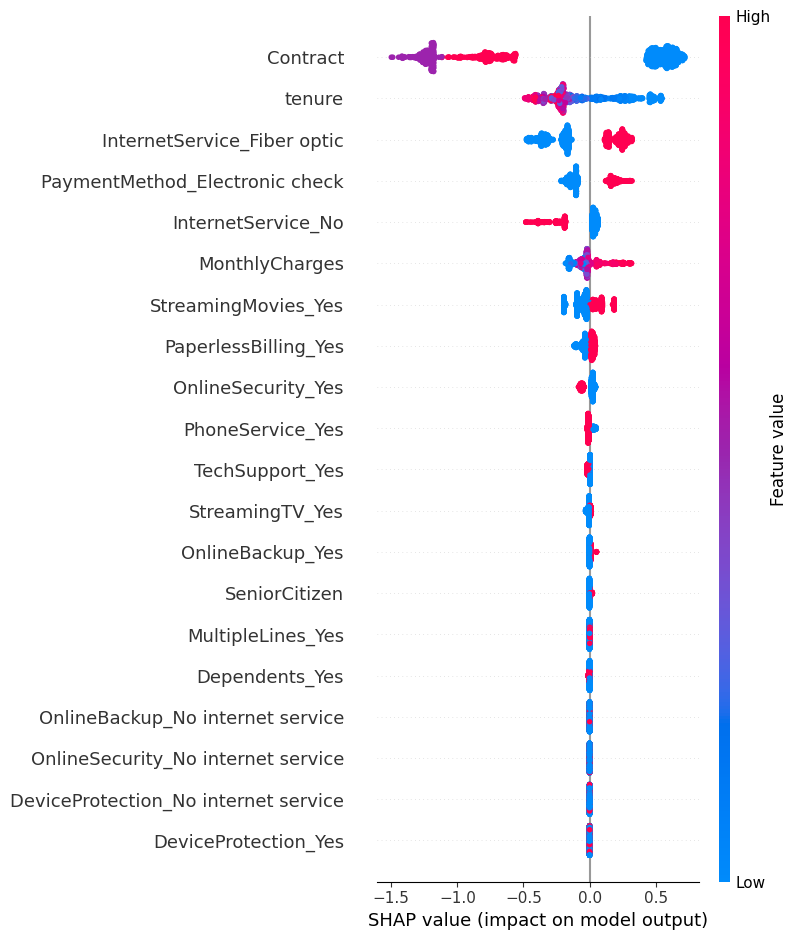

In [192]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

## SHAP Feature Importance

Top churn drivers (in order): Contract type, tenure, InternetService 
(Fiber optic), PaymentMethod (Electronic check), MonthlyCharges.

- Month-to-month contracts strongly increase churn risk; longer contracts 
  (One/Two year) strongly reduce it.
- Low tenure (new customers) increases churn risk, consistent with the 
  bimodal tenure distribution seen in EDA.
- Fiber optic internet and Electronic check payment method both correlate 
  with higher churn.

These findings translate directly into retention strategy: prioritize 
contract upgrades and early-tenure engagement for at-risk customers.

In [193]:
import joblib

joblib.dump(best_xgb, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')   # save this too, in case any future model needs it

['scaler.pkl']

In [198]:
import json
with open('model_columns.json', 'w') as f:
    json.dump(list(X_train.columns), f)